In [1]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
from datetime import datetime
import pickle # for saving simulations
from pybamm import exp, constants
from scipy.optimize import least_squares
from scipy.optimize import minimize
import gzip
import time
import optuna
from scipy.interpolate import interp1d

In [2]:
# Parameter Definitions
# cathode diffusion
def NMC_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("posDiffusion")
    E_D_s = 18550
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# anode diffusion
def graphite_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("negDiffusion")
    E_D_s = 42770
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# cathode kinetics
def NMC_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("posKinetics")
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (
        m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
    )

# anode kinetics
def graphite_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("negKinetics")
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5)

In [ ]:
def calculateRMSE(parameter_values, t_sim, param0, param1, param2, param3, interp_voltage, interp_current):
    spme = pybamm.lithium_ion.SPMe()
    sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, 
                        solver=pybamm.CasadiSolver("safe"))
    sol_0 = sim_0.solve(
        t_eval=t_sim, 
        inputs = {
        "posDiffusion": param0, 
        "negDiffusion": param1, 
        "posKinetics": param2,
        "negKinetics": param3
        })

    t_after = sol_0["Time [s]"].entries
    I_after = sol_0["Current [A]"].entries
    Vt_after = sol_0["Terminal voltage [V]"].entries
    Vt_after1 = np.interp(t_sim, t_after, Vt_after)
    voltage_difference = Vt_after1 - interp_voltage
    rmseOutput = np.sqrt(np.mean(voltage_difference**2))/len(voltage_difference)
    return rmseOutput

In [4]:
def get_initial_stoich(parameter_values, spme, voltage, x_100, y_100, C_n_init, C_p_init,Cap):
    param = spme.param
    eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
    eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))

    parameter_values.update(
        {
            "Negative electrode active material volume fraction": eps_n_init,
            "Positive electrode active material volume fraction": eps_p_init,
            # "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
            # "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
            "Initial temperature [K]": 273.15+25,
            "Ambient temperature [K]": 273.15+25,
            "Lower voltage cut-off [V]": 2.5,
            "Upper voltage cut-off [V]": 4.29
        },check_already_exists=False,)

    initial_voltage=voltage[0]
    model_initV = pybamm.BaseModel()
    param_initV = pybamm.LithiumIonParameters()
    U_n = param_initV.n.prim.U_dimensional
    U_p = param_initV.p.prim.U_dimensional
    T_ref = param_initV.T_ref
    Q_init=0
    print('C_p_init', C_p_init)
    print('C_n_init', C_n_init)
    a0=y_100-(Q_init-Cap)/C_p_init
    a1=x_100+(Q_init-Cap)/C_n_init
    Vmin_init=parameter_values.evaluate(U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref))
    Q_init=Cap
    a2=y_100-(Q_init-Cap)/C_p_init
    a3=x_100+(Q_init-Cap)/C_n_init
    Vmax_init=parameter_values.evaluate(U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref))
    
    print('a0:', a0, '\t a1:', a1, '\t a2:', a2, '\t a3:', a3)
    print('Vmin_init', Vmin_init)
    print('Vmax_init', Vmax_init)
    Q_init = pybamm.Variable("Q_init")
    
    model_initV.algebraic = {Q_init: U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref) - initial_voltage}
    model_initV.initial_conditions = {Q_init: 0.1*Cap}
    model_initV.variables = {
        "Q_init": Q_init,
    }
    
    sim = pybamm.Simulation(model_initV, parameter_values=parameter_values)
    sol = sim.solve([0])
    for var in ["Q_init"]:
        print(var, ":", sol[var].data[0])
    Q_init=sol["Q_init"].data[0]
    xinitV=x_100+(Q_init-Cap)/C_n_init
    yinitV=y_100-(Q_init-Cap)/C_p_init
    print('xinit', xinitV)
    print('yinit', yinitV)
    cs_n_init = parameter_values.evaluate(xinitV* param.n.prim.c_max)
    cs_p_init = parameter_values.evaluate(yinitV* param.p.prim.c_max)
    print('cs_n_init', cs_n_init)
    print('cs_p_init', cs_p_init)

    parameter_values.update(
        {
            "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
            "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        },check_already_exists=False,)

    return parameter_values, spme



In [3]:
cells = [['CELL081', 'P25C', '5P0PSI']] # cells analyzing together
inputDict = {}

for i in range(len(cells)):
    print("Starting to preprocess", str(cells[i]))
    parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
    spme = pybamm.lithium_ion.SPMe()
    hppc_data_raw = pd.DataFrame()
    parameter_values.update(
        {
            "Maximum concentration in positive electrode [mol.m-3]":	31927.3,
            "Maximum concentration in negative electrode [mol.m-3]":	29637,
            "Initial temperature [K]": 273.15+25,
            "Ambient temperature [K]": 273.15+25,
            },check_already_exists=False,)    

    
    if cells[i] == ['CELL041', 'P25C', '5P0PSI']:
        temperature = 25
        C_n_init = 4.0352
        C_p_init = 5.495
        x_init = 0.8613 # x0 or x100 depending on starting at 0 SOC or 1 SOC
        y_init = 0.3096 # use 0 if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC
        Cap=3.48 # update with actual cell capacity.
    elif cells[i] == ['CELL081', 'P25C', '5P0PSI']:
        temperature = 25
        C_n_init = 4.0458
        C_p_init = 5.4828
        x_init = 0.861 # x0 or x100 depending on starting at 0 SOC or 1 SOC
        y_init = 0.3083 # use 0  if a negati if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC
        Cap=3.48
    count = 0
    frames = []

    #load datafile
    df_cycle = pd.read_csv("cell_081_BOL_Cycle1.csv") 
    df_cycle = df_cycle[['Test Time (s)', 'Current (A)','Potential (V)']].drop_duplicates(subset="Test Time (s)").reset_index(drop=True)
    cycle_params = get_initial_stoich(parameter_values.copy(), spme, df_cycle['Potential (V)'], x_init, y_init, C_n_init, C_p_init,Cap)[0]
    item1 = np.array(df_cycle['Test Time (s)'])
    item2 = np.array(df_cycle['Current (A)'])
    item3 = np.array(df_cycle['Potential (V)'])
    item4 = cycle_params
    
    grouping = [item1,item2,item3,item4]
    grouping
    execute_inputDict = {"['CELL081', 'P25C', '5P0PSI']": grouping}
    execute_inputDict
    cycle_index = [0]
    
    parameter_values_list = []
    parameter_values_list.append(get_initial_stoich(parameter_values.copy(), spme, item3, x_init, y_init, C_n_init, C_p_init,Cap)[0])
    data_time = df_cycle["Test Time (s)"].values
    data_current = df_cycle["Current (A)"].values
    data_voltage= df_cycle["Potential (V)"].values


Starting to preprocess ['CELL081', 'P25C', '5P0PSI']


NameError: name 'get_initial_stoich' is not defined

In [ ]:
def calculateRMSE2(parameter_values, t_sim, param0, param1, param2, param3, interp_voltage, interp_current):
    print(len(interp_voltage), len(interp_current), len(t_sim))
    spme = pybamm.lithium_ion.SPMe()
    sim_0 = pybamm.Simulation(spme, parameter_values=cycle_params, 
                        solver=pybamm.CasadiSolver("safe"))

    sol_0 = sim_0.solve(
        t_eval=t_sim, 
        inputs = {
        "posDiffusion": param0, 
        "negDiffusion": param1, 
        "posKinetics": param2,
        "negKinetics": param3
        })

    t_after = sol_0["Time [s]"].entries
    I_after = sol_0["Current [A]"].entries
    Vt_after = sol_0["Terminal voltage [V]"].entries

    # Create dataframe of results
    Vt_after1 = np.interp(t_sim, t_after, Vt_after)
    voltage_difference = (t_sim - interp_voltage)
    rmseOutput = np.sqrt(np.mean(voltage_difference**2))/len(voltage_difference)
    plt.plot(t_after, Vt_after, label='model Voltage')
    plt.plot(t_sim, interp_voltage, label='measured Voltage')
    plt.legend()
    plt.show()
    print(Vt_after[0], interp_voltage[0])
    plt.plot(t_after,I_after, label="current model")
    print(len(I_after)),
    print(I_after)
    return rmseOutput


def objectiveProcessing2(trial, execute_inputDict, cells,df_cycle, cycle_index):
    param0= 1.9255412756549457e-15
    param1= 3.3178783184328414e-13
    param2= 2.1108716025262534e-05
    param3= 5.762795921421079e-07
    rmseAll = []   
    for i in range(len(cells)):
        rmse = np.zeros(len(df_cycle))
        for j in range(len(df_cycle)):
            t_sim = item1
            interp_current = item2
            interp_voltage = item3
            parameter_values = item4.copy()
            parameter_values.update(
                {
                    "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
                    "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
                    "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
                    "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
                    })           
            rmseOutput = calculateRMSE2(cycle_params, t_sim, param0, param1, param2, param3, interp_voltage, interp_current)
            rmse[j] = rmseOutput
        rmseAll.append(rmse)
    rmseAverage = np.sum(rmseAll)/len(rmseAll)
    print("guess parameters and average RMSE: ", param0, param1, param2, param3, rmseAverage)
    return rmseAverage

def execute_2(execute_inputDict, cells, df_cycle, cycle_index):
    print("Starting optimization of cells", str(cells))
    def objective_function(trial):
        rmseAverage = objectiveProcessing2(trial, execute_inputDict, cells, df_cycle, cycle_index)
        return rmseAverage
    results = objective_function(1)
    return results

execute_2(execute_inputDict, cells, [df_cycle], cycle_index)
cycle_index

In [ ]:
#Execution: 


execute_inputDict, cells, [df_cycle], cycle_index

Starting to preprocess ['CELL081', 'P25C', '5P0PSI']
C_p_init 5.4828
C_n_init 4.0458
a0: 0.9430121908513898 	 a1: 0.0008487320183894198 	 a2: 0.3083 	 a3: 0.861
Vmin_init [[2.66163844]]
Vmax_init [[4.20101306]]
Q_init : 0.050927603284697275
xinit 0.013436502863388489
yinit 0.9337235785940218
cs_n_init 398.21763536224466
cs_p_init 29811.272810844912
C_p_init 5.4828
C_n_init 4.0458
a0: 0.9430121908513898 	 a1: 0.0008487320183894198 	 a2: 0.3083 	 a3: 0.861
Vmin_init [[2.66163844]]
Vmax_init [[4.20101306]]
Q_init : 0.050927603284697275
xinit 0.013436502863388489
yinit 0.9337235785940218
cs_n_init 398.21763536224466
cs_p_init 29811.272810844912


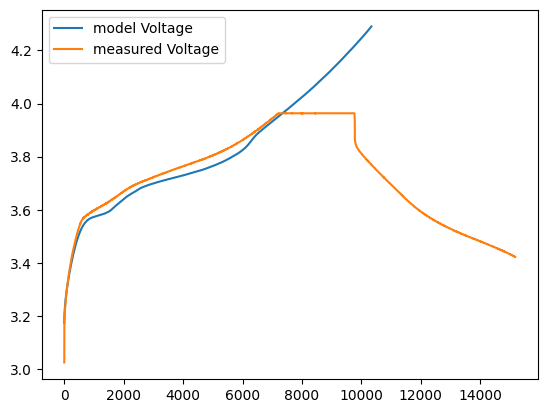

3.1743046065079237 3.0251
10336
[-1.1667 -1.1667 -1.1667 ... -1.1667 -1.1667 -1.1667]


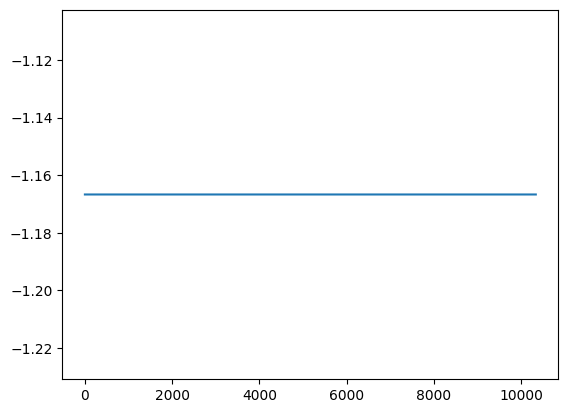

In [28]:
cells = [['CELL081', 'P25C', '5P0PSI']] # cells analyzing together
inputDict = {}

for i in range(len(cells)):
    print("Starting to preprocess", str(cells[i]))
    parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
    spme = pybamm.lithium_ion.SPMe()
    hppc_data_raw = pd.DataFrame()
    parameter_values.update(
        {
            "Maximum concentration in positive electrode [mol.m-3]":	31927.3,
            "Maximum concentration in negative electrode [mol.m-3]":	29637,
            "Initial temperature [K]": 273.15+25,
            "Ambient temperature [K]": 273.15+25,
            },check_already_exists=False,)    

    path = "W:\\UM\\Cell81_16_41\\"
    with open(path + str(cells[i]) + ".pickle", "rb") as f:
        combinedDict = pickle.load(f)

    if cells[i] == ['CELL041', 'P25C', '5P0PSI']:
        temperature = 25
        C_n_init = 4.0352
        C_p_init = 5.495
        x_init = 0.8613 # x0 or x100 depending on starting at 0 SOC or 1 SOC
        y_init = 0.3096 # use 0 if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC
        Cap=3.48 # update with actual cell capacity.
    elif cells[i] == ['CELL081', 'P25C', '5P0PSI']:
        temperature = 25
        C_n_init = 4.0458
        C_p_init = 5.4828
        x_init = 0.861 # x0 or x100 depending on starting at 0 SOC or 1 SOC
        y_init = 0.3083 # use 0  if a negati if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC
        Cap=3.48
    count = 0
    frames = []

    #load datafile
    df_cycle = pd.read_csv("cell_081_BOL_Cycle1.csv") 
    df_cycle = df_cycle[['Test Time (s)', 'Current (A)','Potential (V)']].drop_duplicates(subset="Test Time (s)").reset_index(drop=True)
    cycle_params = get_initial_stoich(parameter_values.copy(), spme, df_cycle['Potential (V)'], x_init, y_init, C_n_init, C_p_init,Cap)[0]
    item1 = np.array(df_cycle['Test Time (s)'])
    item2 = np.array(df_cycle['Current (A)'])
    item3 = np.array(df_cycle['Potential (V)'])
    item4 = cycle_params
    grouping = [item1,item2,item3,item4]
    grouping
    execute_inputDict = {"['CELL081', 'P25C', '5P0PSI']": grouping}
    execute_inputDict
    cycle_index = [0]
    
    parameter_values_list = []
    parameter_values_list.append(get_initial_stoich(parameter_values.copy(), spme, item3, x_init, y_init, C_n_init, C_p_init,Cap)[0])



    param0= 1.9255412756549457e-15
    param1= 3.3178783184328414e-13
    param2= 2.1108716025262534e-05
    param3= 5.762795921421079e-07
    rmseAll = []   
    
    for i in range(len(cells)):
        rmse = np.zeros(len(df_cycle))
        t_sim = item1
        interp_current = -item2
        interp_voltage = item3
        parameter_values = item4
        parameter_values.update(
            {
                "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
                "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
                "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
                "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
                })           
    parameter_values["Current function [A]"] = pybamm.Interpolant(t_sim[(t_sim>2) * (t_sim<1400)], interp_current[(t_sim>2) * (t_sim<1400)], pybamm.t)
    
    spme = pybamm.lithium_ion.SPMe()
    sim_0 = pybamm.Simulation(spme, parameter_values=cycle_params, 
                        solver=pybamm.CasadiSolver("safe"))

    sol_0 = sim_0.solve(
        t_eval=t_sim, 
        inputs = {
        "posDiffusion": param0, 
        "negDiffusion": param1, 
        "posKinetics": param2,
        "negKinetics": param3
        })

    t_after = sol_0["Time [s]"].entries
    I_after = sol_0["Current [A]"].entries
    Vt_after = sol_0["Terminal voltage [V]"].entries

    # Create dataframe of results
    Vt_after1 = np.interp(t_sim, t_after, Vt_after)
    voltage_difference = (t_sim - interp_voltage)
    rmseOutput = np.sqrt(np.mean(voltage_difference**2))/len(voltage_difference)
    plt.plot(t_after, Vt_after, label='model Voltage')
    plt.plot(t_sim, interp_voltage, label='measured Voltage')
    plt.legend()
    plt.show()
    print(Vt_after[0], interp_voltage[0])
    plt.plot(t_after,I_after, label="current model")
    print(len(I_after)),
    print(I_after)

In [12]:
sol_0.data["Time [s]"]

array([ 0.       ,  1.       ,  2.       ,  3.       ,  4.       ,
        5.       ,  6.       ,  7.       ,  8.       ,  9.       ,
       10.       , 11.       , 12.       , 13.       , 14.       ,
       15.       , 16.       , 17.       , 18.       , 19.       ,
       20.       , 21.       , 22.       , 23.       , 23.0985155])

In [14]:
sol_0.data["Current [A]"]

array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3.])

In [29]:
sol_0.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=2.8705867494809687, step=0.02870586749480968…

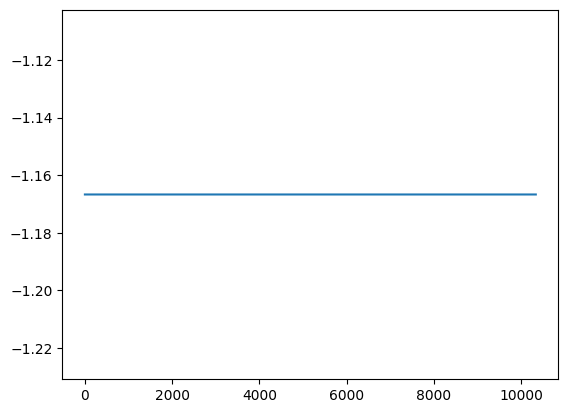

In [33]:
plt.plot(sol_0.data['Time [s]'],sol_0.data['Current [A]'])